### This project focuses on analyzing Netflix’s userbase to uncover insights related to customer churn, revenue impact, device usage, and predictive modeling. The goal is to identify at-risk users, reduce churn, and improve retention strategies to maximize user engagement and revenue.



#### Importing Libraries 

In [176]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

import warnings

In [177]:
# Here we are setting an option to show the full width of the column, all the colums will be displayed, along with that 2000 rows will be displayed for eacb column.
pd.set_option('display.max_colwidth', 0)
pd.set_option('display.max_columns', None)
pd.options.display.max_seq_items = 200
warnings.filterwarnings('ignore')

#### Date-set Loading 

In [179]:
# Load the dataset
file_path = 'Netflix Userbase.csv'
netflix_data = pd.read_csv(file_path)
netflix_data.head(10)

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
5,6,Premium,15,18-03-22,27-06-23,France,29,Female,Smart TV,1 Month
6,7,Standard,12,09-12-21,25-06-23,Brazil,46,Male,Tablet,1 Month
7,8,Basic,10,02-04-23,24-06-23,Mexico,39,Female,Laptop,1 Month
8,9,Standard,12,20-10-22,23-06-23,Spain,37,Male,Smartphone,1 Month
9,10,Premium,15,07-01-23,22-06-23,Italy,44,Female,Smart TV,1 Month


In [180]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   User ID            2500 non-null   int64 
 1   Subscription Type  2500 non-null   object
 2   Monthly Revenue    2500 non-null   int64 
 3   Join Date          2500 non-null   object
 4   Last Payment Date  2500 non-null   object
 5   Country            2500 non-null   object
 6   Age                2500 non-null   int64 
 7   Gender             2500 non-null   object
 8   Device             2500 non-null   object
 9   Plan Duration      2500 non-null   object
dtypes: int64(3), object(7)
memory usage: 195.4+ KB


#### Customer Segmentation 

- The goal is to group users based on shared characteristics such as demographics, subscription preferences, and usage behavior. These segments help businesses understand different user groups and tailor marketing, product offerings, and customer retention strategies.

#### Age wise distribution 

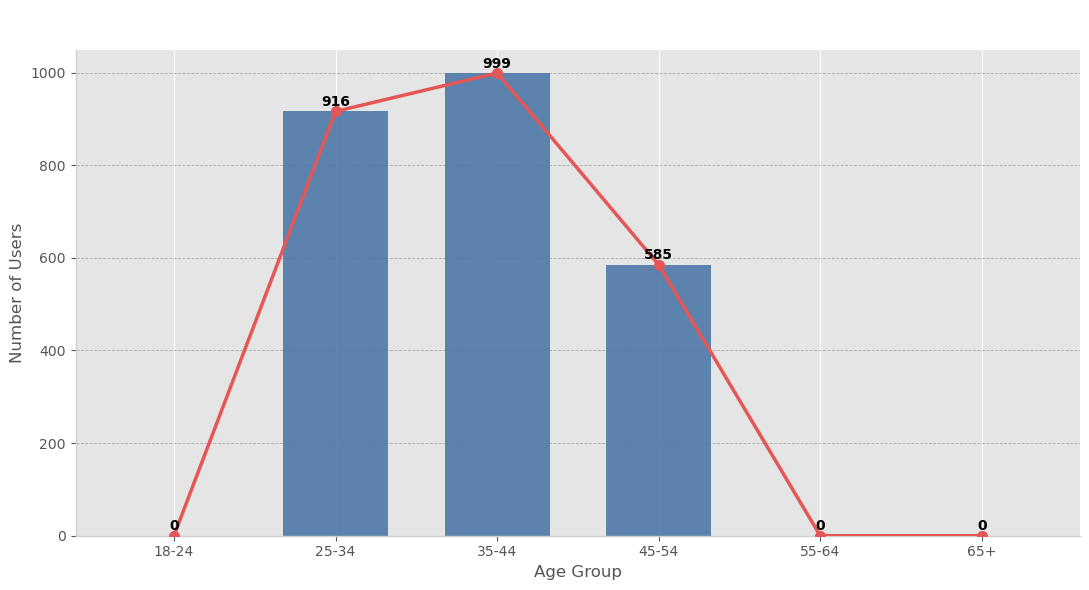

In [184]:
# Age groups
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
netflix_data['Age Group'] = pd.cut(
    netflix_data['Age'],
    bins=age_bins,
    labels=age_labels
)
age_group_distribution = (
    netflix_data['Age Group']
    .value_counts()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(11,6))
bars = ax.bar(
    age_group_distribution.index,
    age_group_distribution.values,
    color="#4C78A8",
    width=0.65,
    alpha=0.9
)
x = np.arange(len(age_group_distribution))
ax.plot(
    x,
    age_group_distribution.values,
    color="#E45756",
    linewidth=2.5,
    marker="o",
    markersize=7,
    zorder=5
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        zorder=10       
    )
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D0D0D0')
ax.spines['bottom'].set_color('#D0D0D0')
ax.set_title(
    "Netflix User Distribution by Age Group",
    fontsize=18,
    weight='bold',
    pad=15
)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Number of Users", fontsize=12)

plt.tight_layout()
plt.show()

#### Observation:-The majority of users are in the 25-34 and 35-44 age groups, indicating that Netflix users are typically within these age ranges.

### Gender wise distribution

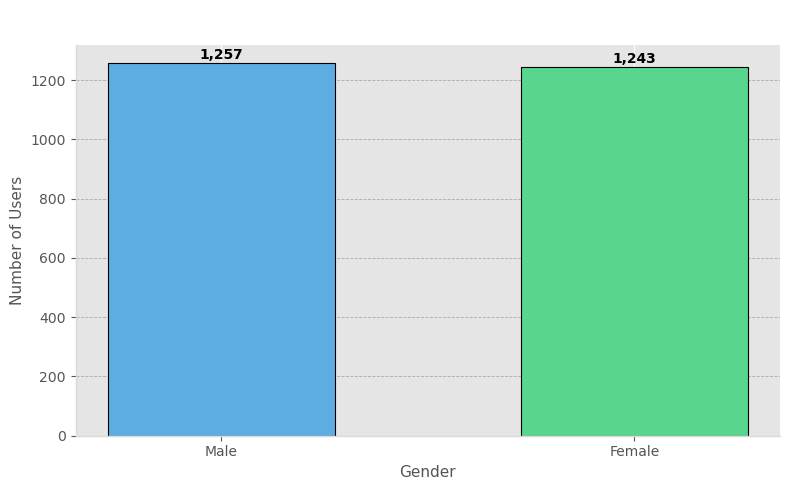

In [187]:
gender_counts = netflix_data['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['Male', 'Female'],
    gender_counts.values,
    color=['#5DADE2', '#58D68D'],
    edgecolor='black',
    linewidth=0.8,
    width=0.55
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')
ax.set_title(
    'Gender Distribution of Netflix Users',
    fontsize=16,
    fontweight='bold',
    pad=12
)

ax.set_xlabel('Gender', fontsize=11)
ax.set_ylabel('Number of Users', fontsize=11)

plt.tight_layout()
plt.show()

#### Observation:- The gender distribution is relatively balanced, with both Male and Female users having similar representation.

#### Country wise Distribution 

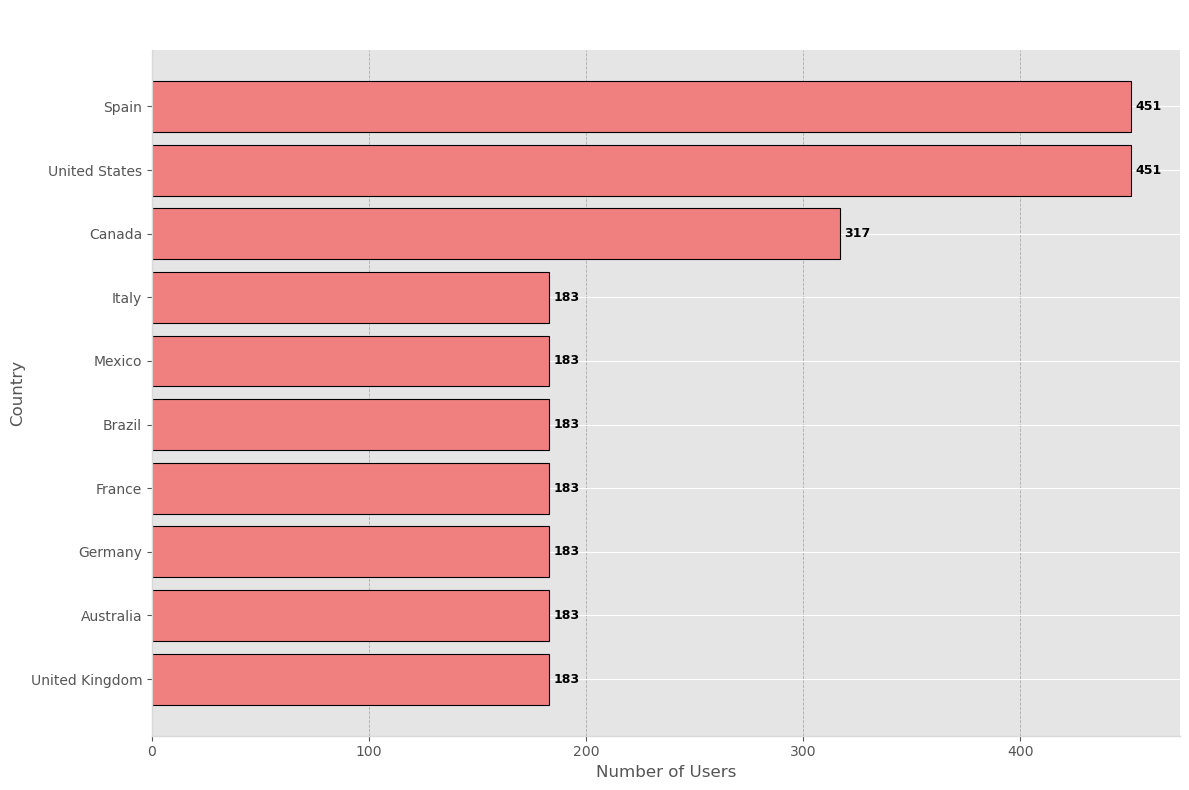

In [190]:
country_counts = netflix_data['Country'].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    country_counts.index,
    country_counts.values,
    color="#F08080",
    edgecolor="black",
    linewidth=0.8
)
for bar in bars:
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width()):,}',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )
ax.grid(
    axis='x',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Country Distribution of Netflix Users',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Number of Users', fontsize=12)
ax.set_ylabel('Country', fontsize=12)

plt.tight_layout()
plt.show()

#### Observation:-The largest user bases are from countries like the United States, Canada, and United Kingdom, with smaller groups from other                  countries.

#### Categorise User type / Subscription type into age groups 

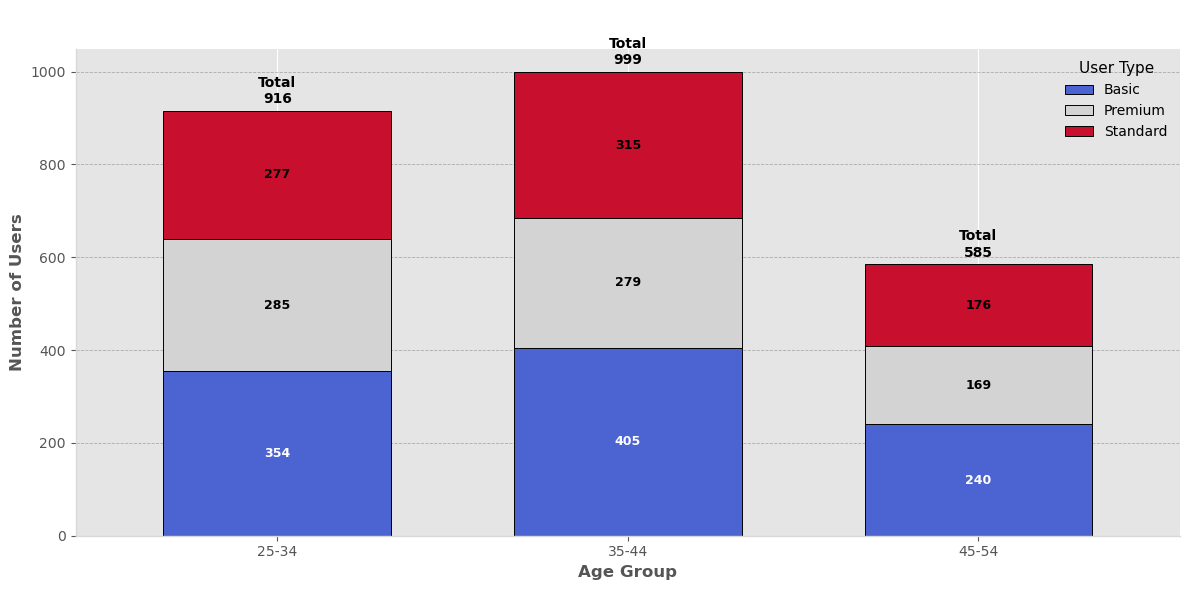

In [193]:
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

netflix_data['Age Group'] = pd.cut(
    netflix_data['Age'],
    bins=age_bins,
    labels=age_labels
)
age_group_subscription = (
    netflix_data
    .groupby('Age Group')['Subscription Type']
    .value_counts()
    .unstack(fill_value=0)
)
age_group_subscription = age_group_subscription.loc[
    age_group_subscription.sum(axis=1) > 0
]
age_group_subscription = age_group_subscription[
    ['Basic', 'Premium', 'Standard']
]
fig, ax = plt.subplots(figsize=(12,6))

colors = [
    '#4C63D2',   # Basic
    '#D3D3D3',   # Premium
    '#C8102E'    # Standard
]

age_group_subscription.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')
ax.set_title(
    'Subscription Type by Age Group',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Age Group',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Users',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
for container in ax.containers:

    for bar in container:

        height = bar.get_height()

        if height > 0:

            facecolor = bar.get_facecolor()

            # White text on dark bars
            if facecolor[0] < 0.75:
                txt_color = "white"
            else:
                txt_color = "black"

            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f'{int(height)}',
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color=txt_color
            )

totals = age_group_subscription.sum(axis=1)

for i, total in enumerate(totals):

    ax.text(
        i,
        total + 10,
        f'Total\n{int(total)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )
legend = ax.legend(
    title='User Type',
    labels=['Basic', 'Premium', 'Standard'],
    frameon=False,
    fontsize=10,
    title_fontsize=11,
    loc='upper right'
)

plt.setp(legend.get_texts(), color='black')
plt.setp(legend.get_title(), color='black')

plt.tight_layout()
plt.show()

#### Observation:-  Users are spread across the Basic, Standard, and Premium subscription plans, with the Basic plan being the most popular.

#### Subscription type by gender

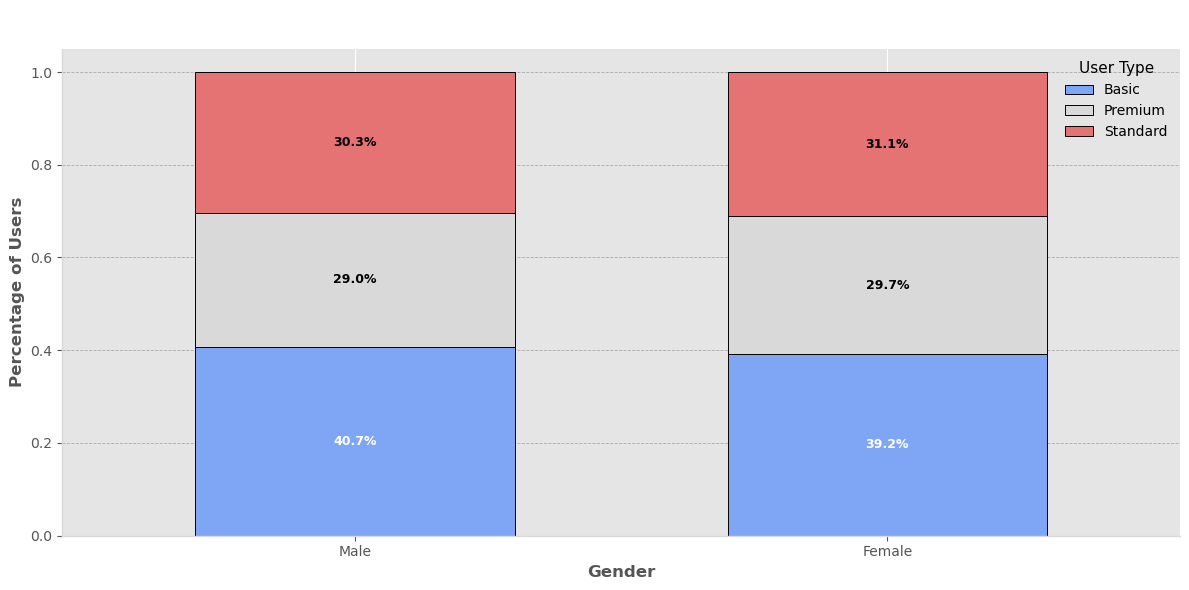

In [196]:
import matplotlib.pyplot as plt

gender_subscription = (
    netflix_data
    .groupby('Gender')['Subscription Type']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

gender_subscription = gender_subscription[
    ['Basic', 'Premium', 'Standard']
]

fig, ax = plt.subplots(figsize=(12,6))

colors = [
    '#7FA6F5',
    '#D9D9D9',
    '#E57373'
]

gender_subscription.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=0.7,
    width=0.6
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Subscription Type by Gender',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Gender',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Percentage of Users',
    fontsize=12,
    fontweight='bold'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Male', 'Female'], rotation=0)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        if height > 0.03:
            facecolor = bar.get_facecolor()
            txt_color = "white" if facecolor[0] < 0.8 else "black"

            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f'{height:.1%}',
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color=txt_color
            )

legend = ax.legend(
    title='User Type',
    frameon=False,
    fontsize=10,
    title_fontsize=11,
    loc='upper right'
)

plt.setp(legend.get_texts(), color='black')
plt.setp(legend.get_title(), color='black')

plt.tight_layout()
plt.show()

#### Observation:- Gender has no impact on subscription

#### Revenue Analysis

-This analysis focuses on understanding the revenue streams across various user segments. Key metrics such as Average Revenue Per User (ARPU), total revenue by subscription type, revenue by country, and revenue by device will provide insights into where the most revenue is coming from and how it varies across segments.

#### Total Revenue and Average Revenue Per User/Subscription Type (ARPU)¶

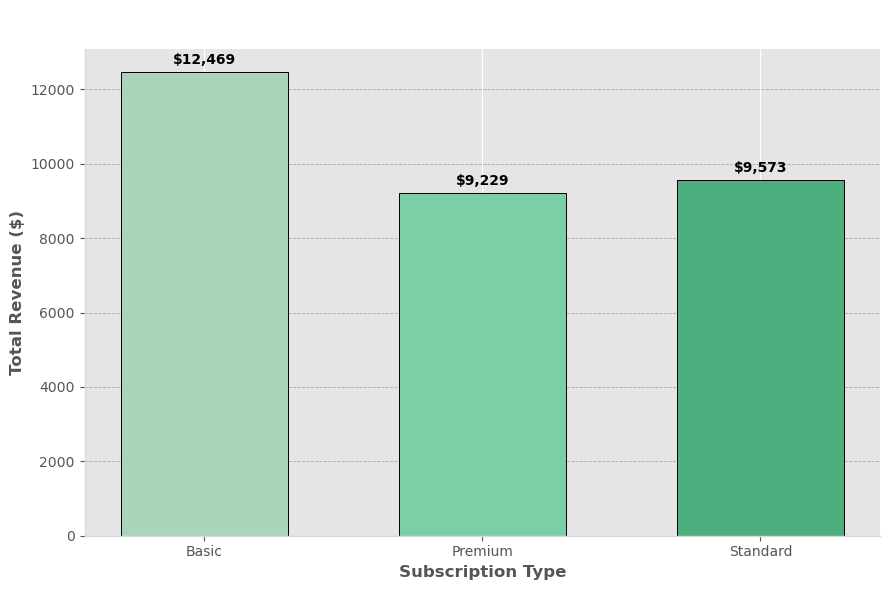

In [201]:
revenue_by_subscription = (
    netflix_data
    .groupby('Subscription Type')['Monthly Revenue']
    .sum()
    .reindex(['Basic', 'Premium', 'Standard'])
)

fig, ax = plt.subplots(figsize=(9,6))

colors = [
    '#A8D5BA',   # Basic
    '#7BCFA6',   # Premium
    '#4CAF7D'    # Standard
]

bars = ax.bar(
    revenue_by_subscription.index,
    revenue_by_subscription.values,
    color=colors,
    edgecolor='black',
    linewidth=0.7,
    width=0.6
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Revenue by Subscription Type',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Subscription Type',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Total Revenue ($)',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + max(revenue_by_subscription.values)*0.01,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

#### Observation :- The Premium plan generates the most revenue, followed by Standard and Basic plans. This indicates that users on higher-tier   subscriptions contribute significantly more to the overall revenue.

#### Revenue by country 

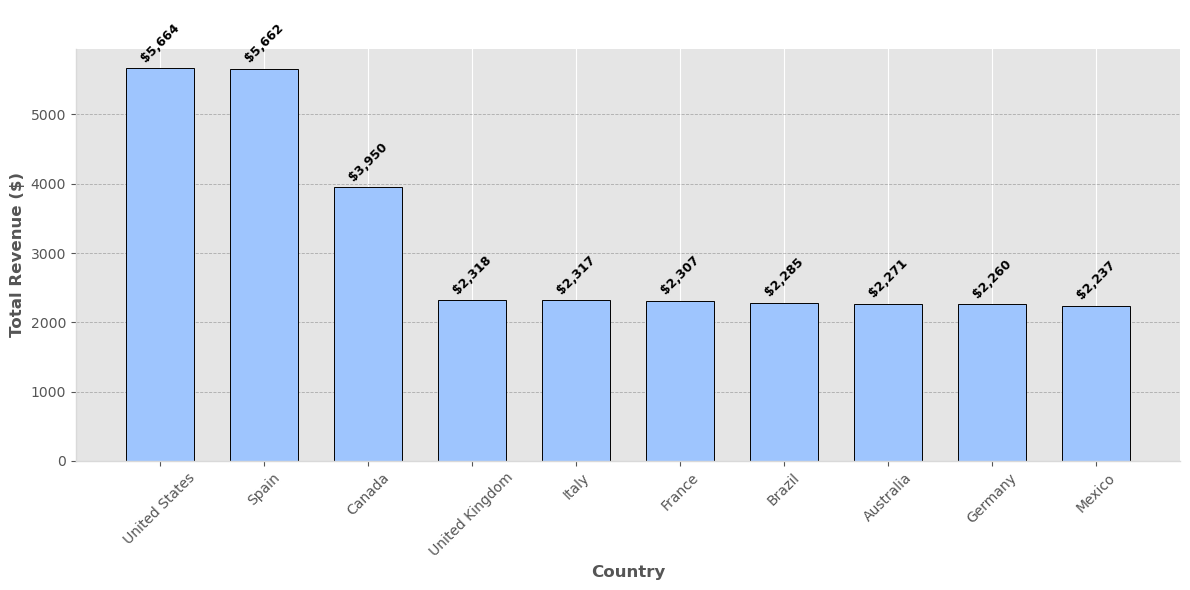

In [204]:
import matplotlib.pyplot as plt

revenue_by_country = (
    netflix_data
    .groupby('Country')['Monthly Revenue']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    revenue_by_country.index,
    revenue_by_country.values,
    color='#9EC5FE',
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Revenue by Country',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Country',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Total Revenue ($)',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + max(revenue_by_country.values)*0.01,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        rotation=45,
        color='black'
    )

plt.tight_layout()
plt.show()

#### Obsrvation :- Countries like the United States, Canada, and the United Kingdom generate the highest revenue, with other countries contributing less in comparison. This reflects the geographic concentration of revenue generation.

#### Revenue by Devices

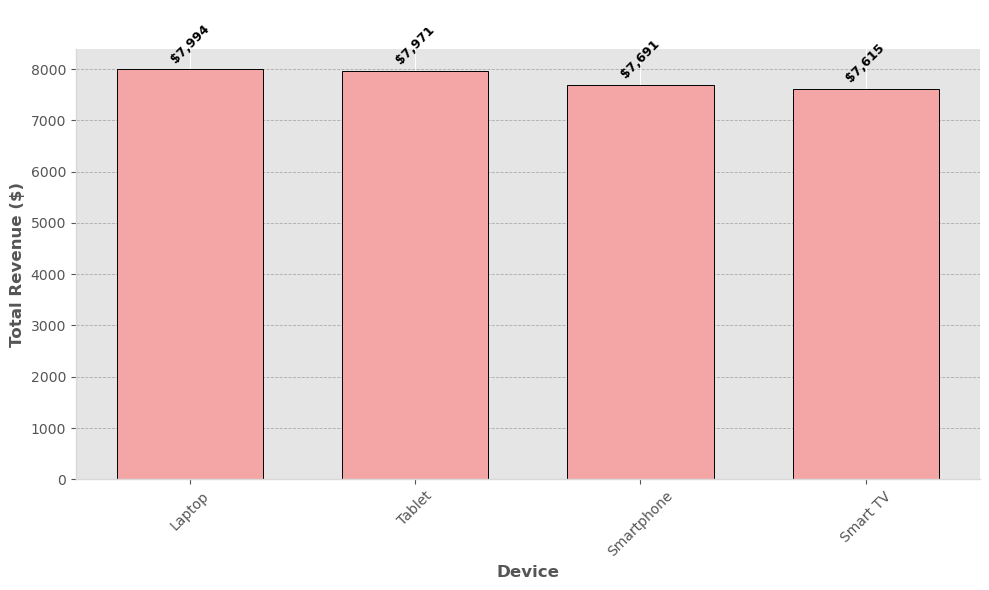

In [207]:
import matplotlib.pyplot as plt

revenue_by_device = (
    netflix_data
    .groupby('Device')['Monthly Revenue']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    revenue_by_device.index,
    revenue_by_device.values,
    color='#F4A6A6',
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Revenue by Device',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Device',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Total Revenue ($)',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(
    axis='x',
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis='y',
    labelsize=10
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + max(revenue_by_device.values)*0.01,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        rotation=45,
        color='black'
    )

plt.tight_layout()
plt.show()

#### Observation :- Smart TVs and Tablets generate the most revenue, followed by Smartphones and Laptops. This suggests that users accessing Netflix on larger screens tend to subscribe to higher-tier plans. 

#### Churn and Retention Analysis

- To conduct a detailed Crunch Analysis, we’ll focus on identifying churn patterns, potential drivers of churn, and quantifying the impact of churn on revenue and business growth.

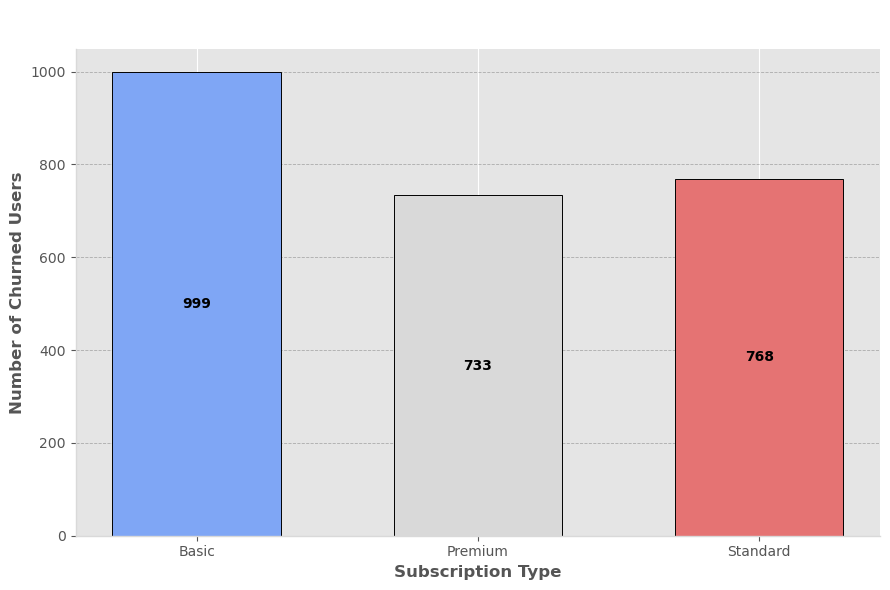

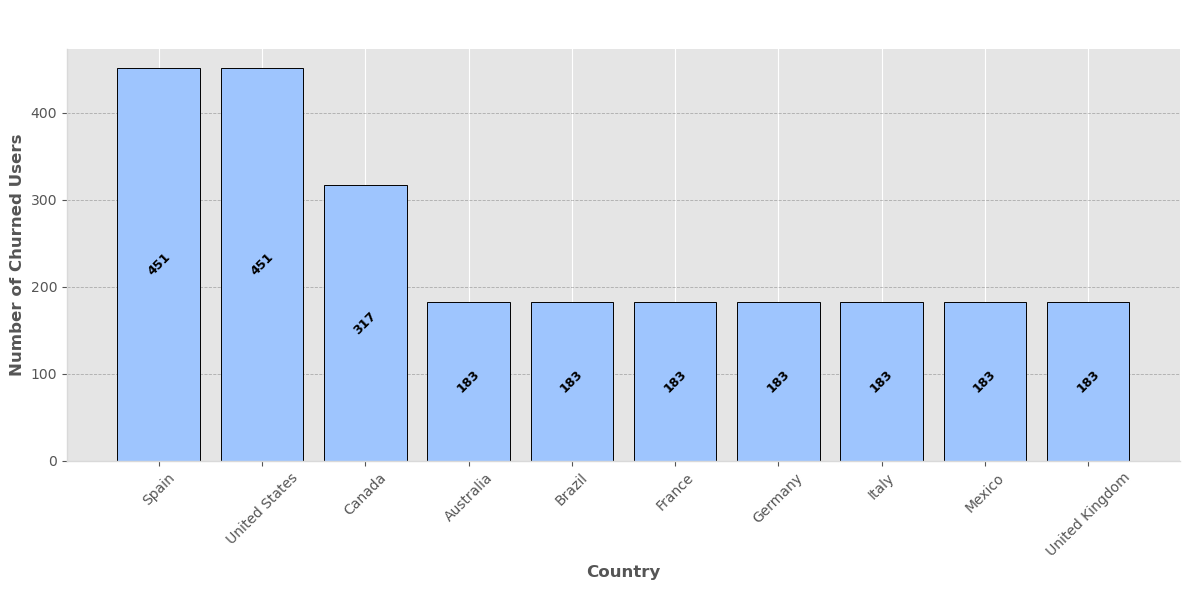

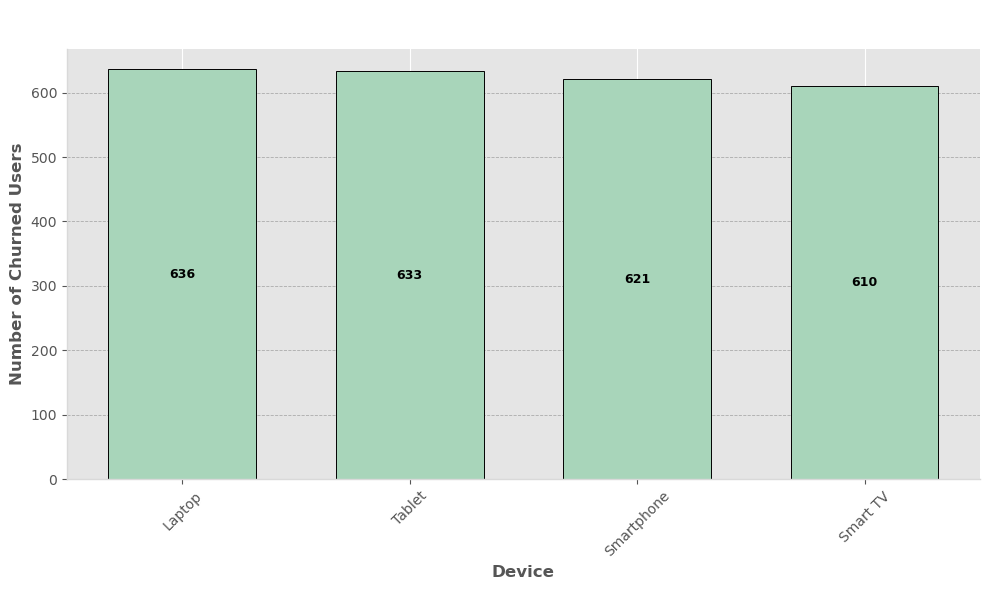

Total Revenue Lost Due to Churn : $31,271


In [211]:
import pandas as pd
import matplotlib.pyplot as plt

netflix_data = pd.read_csv("Netflix Userbase.csv")

netflix_data['Join Date'] = pd.to_datetime(
    netflix_data['Join Date'],
    format='%d-%m-%y'
)

netflix_data['Last Payment Date'] = pd.to_datetime(
    netflix_data['Last Payment Date'],
    format='%d-%m-%y'
)

today = pd.Timestamp.today()

netflix_data['Days Since Last Payment'] = (
    today - netflix_data['Last Payment Date']
).dt.days

netflix_data['Churn'] = netflix_data['Days Since Last Payment'] > 30

# ---------------------------------------------------------
# Churn by Subscription Type
# ---------------------------------------------------------

churn_by_subscription_type = (
    netflix_data.loc[netflix_data['Churn']]
    .groupby('Subscription Type')
    .size()
    .reindex(['Basic','Premium','Standard'])
)

fig, ax = plt.subplots(figsize=(9,6))

colors = ['#7FA6F5','#D9D9D9','#E57373']

bars = ax.bar(
    churn_by_subscription_type.index,
    churn_by_subscription_type.values,
    color=colors,
    edgecolor='black',
    linewidth=0.7,
    width=0.6
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Churn by Subscription Type',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Subscription Type',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Churned Users',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        height*0.5,
        f'{int(height)}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Churn by Country
# ---------------------------------------------------------

churn_by_country = (
    netflix_data.loc[netflix_data['Churn']]
    .groupby('Country')
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    churn_by_country.index,
    churn_by_country.values,
    color='#9EC5FE',
    edgecolor='black',
    linewidth=0.7
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Churn by Country',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Country',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Churned Users',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(axis='x', rotation=45)

for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        height*0.5,
        f'{int(height)}',
        ha='center',
        va='center',
        rotation=45,
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Churn by Device
# ---------------------------------------------------------

churn_by_device = (
    netflix_data.loc[netflix_data['Churn']]
    .groupby('Device')
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    churn_by_device.index,
    churn_by_device.values,
    color='#A8D5BA',
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Churn by Device',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Device',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Churned Users',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(axis='x', rotation=45)

for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        height*0.5,
        f'{int(height)}',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Revenue Lost Due to Churn
# ---------------------------------------------------------

revenue_lost = (
    netflix_data.loc[
        netflix_data['Churn'],
        'Monthly Revenue'
    ].sum()
)

print("="*45)
print(f"Total Revenue Lost Due to Churn : ${revenue_lost:,.0f}")
print("="*45)

#### Findings from Churn Crunch Analysis:
 - 1. Churn by Subscription Type:
A significant number of users have churned across all subscription types, with Premium users showing a higher churn count. This highlights potential retention issues across all subscription plans, especially for premium users.
 - 2. Churn by Country:
The churn is distributed across countries, with countries like the United States, Canada, and United Kingdom having a higher number of churned users.
 - 3. Churn by Device:
Users accessing Netflix via Smartphones and Tablets have higher churn rates compared to those using Smart TVs and Laptops. This suggests that mobile users might be more prone to churn.
 - 4. Revenue Lost Due to Churn:
The total revenue lost due to churn amounts to $31,271. This represents a significant loss in potential revenue, emphasizing the need for targeted retention strategies.

#### Device Usage Analysis 

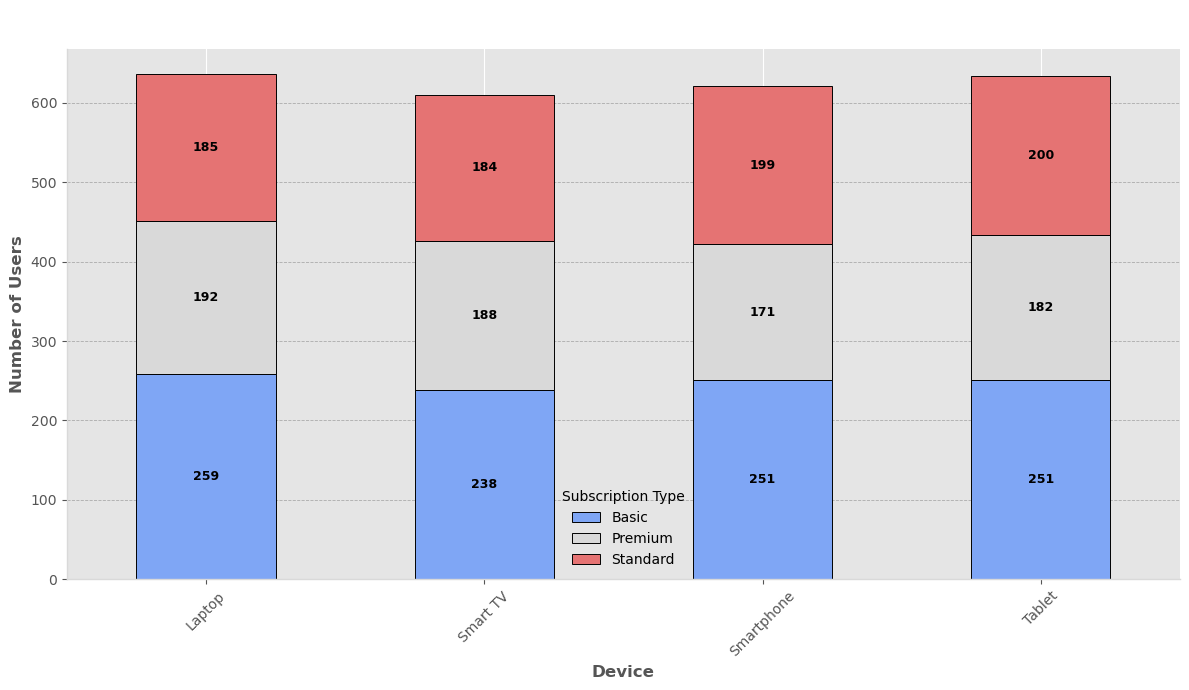

In [214]:
import matplotlib.pyplot as plt
import pandas as pd

device_by_subscription = pd.crosstab(
    netflix_data['Device'],
    netflix_data['Subscription Type']
)

device_by_subscription = device_by_subscription[
    ['Basic', 'Premium', 'Standard']
]

colors = ['#7FA6F5', '#D9D9D9', '#E57373']

fig, ax = plt.subplots(figsize=(12,7))

device_by_subscription.plot(
    kind='bar',
    stacked=True,
    color=colors,
    edgecolor='black',
    linewidth=0.7,
    ax=ax
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Device Usage by Subscription Type',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Device',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Users',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(
    axis='x',
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis='y',
    labelsize=10
)

for container in ax.containers:
    labels = [
        f'{int(v.get_height())}' if v.get_height() > 0 else ''
        for v in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

legend = ax.legend(
    title='Subscription Type',
    frameon=False
)

plt.setp(
    legend.get_texts(),
    color='black'
)

plt.setp(
    legend.get_title(),
    color='black'
)

plt.tight_layout()
plt.show()

#### Revenue by Device 
- Revenue by Device
This analysis will help us understand how the Netflix user base and payment trends have evolved over time

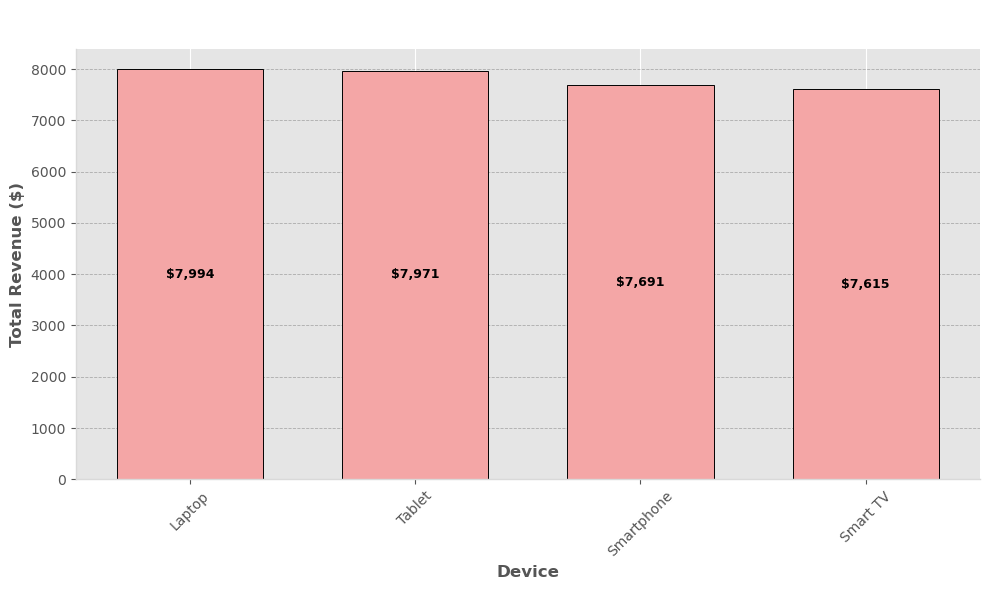

In [216]:
import matplotlib.pyplot as plt

revenue_by_device = (
    netflix_data
    .groupby('Device')['Monthly Revenue']
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    revenue_by_device.index,
    revenue_by_device.values,
    color='#F4A6A6',
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    color='black',
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#D9D9D9')
ax.spines['bottom'].set_color('#D9D9D9')

ax.set_title(
    'Revenue by Device',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Device',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Total Revenue ($)',
    fontsize=12,
    fontweight='bold'
)

ax.tick_params(
    axis='x',
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis='y',
    labelsize=10
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height * 0.5,
        f'${height:,.0f}',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

#### Findings from the Device Usage Analysis:
- 1. Device Usage by Subscription Type:
Smartphones and Tablets are popular across all subscription types (Basic, Standard, and Premium). However, Smart TVs and Laptops have a more even distribution, indicating that users on higher subscription tiers may prefer larger screen devices for an enhanced viewing experience.
- 2. Revenue by Device:
Smart TVs and Tablets generate the highest revenue, followed by Smartphones and Laptops. This suggests that users who prefer watching Netflix on larger screens or mobile devices are more likely to contribute significantly to the overall revenue.

#### Time based Analysis 

 - Time-Based Analysis
This analysis will help us understand how the Netflix user base and payment trends have evolved over time.

#### User-Growth per time 

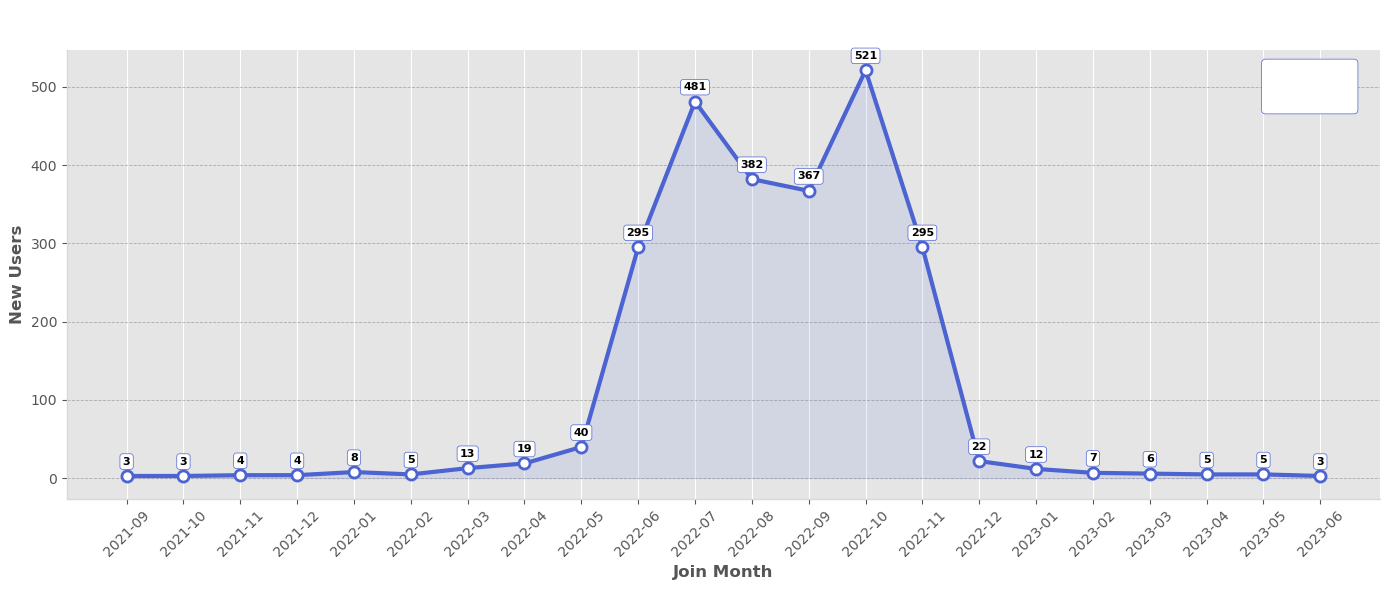

In [221]:
import matplotlib.pyplot as plt

user_growth = (
    netflix_data['Join Date']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

x = range(len(user_growth))

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(
    x,
    user_growth.values,
    color="#4C63D2",
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgecolor="#4C63D2",
    markeredgewidth=2
)

ax.fill_between(
    x,
    user_growth.values,
    color="#4C63D2",
    alpha=0.12
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    color="black",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D9D9D9")
ax.spines["bottom"].set_color("#D9D9D9")

ax.set_title(
    "Monthly User Growth Trend",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Join Month",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "New Users",
    fontsize=12,
    fontweight="bold"
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    user_growth.index.astype(str),
    rotation=45
)

for i, value in enumerate(user_growth.values):

    ax.text(
        i,
        value + 12,
        str(value),
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="#4C63D2",
            boxstyle="round,pad=0.25"
        )
    )

peak_month = user_growth.idxmax()
peak_value = user_growth.max()

ax.text(
    0.98,
    0.97,
    f"Peak Growth\n{peak_month.strftime('%b %Y')}\n{peak_value} Users",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#4C63D2",
        boxstyle="round"
    )
)

plt.tight_layout()
plt.show()

#### Payment trends over time 

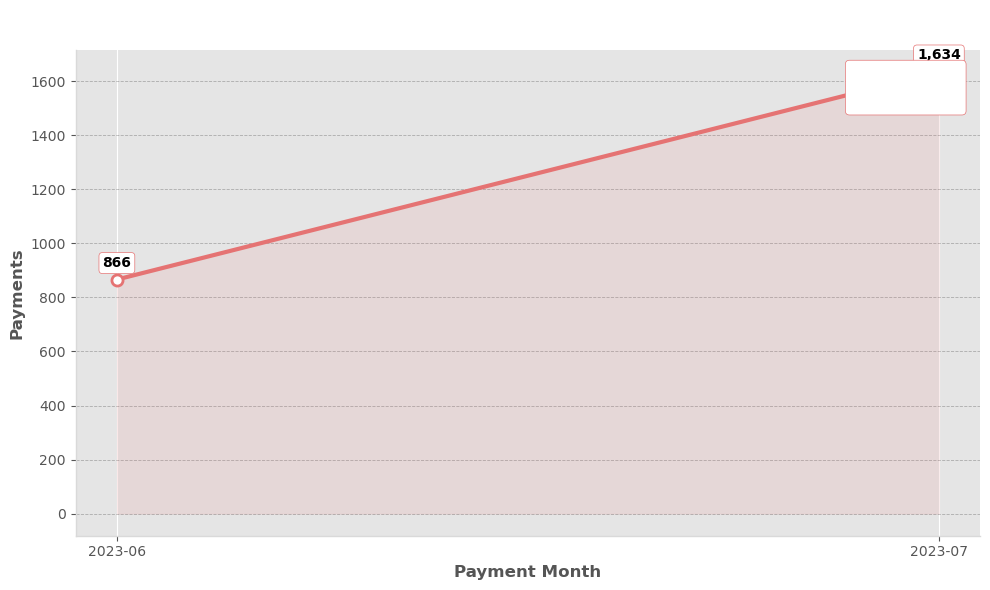

In [223]:
payment_trends = (
    netflix_data['Last Payment Date']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

x = range(len(payment_trends))

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    x,
    payment_trends.values,
    color="#E57373",
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgecolor="#E57373",
    markeredgewidth=2
)

ax.fill_between(
    x,
    payment_trends.values,
    color="#E57373",
    alpha=0.12
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    color="black",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#D9D9D9")
ax.spines["bottom"].set_color("#D9D9D9")

ax.set_title(
    "Monthly Payment Activity",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Payment Month",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Payments",
    fontsize=12,
    fontweight="bold"
)

ax.set_xticks(list(x))
ax.set_xticklabels(payment_trends.index.astype(str))

for i, value in enumerate(payment_trends.values):

    ax.text(
        i,
        value + 35,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="#E57373",
            boxstyle="round,pad=0.25"
        )
    )

peak_month = payment_trends.idxmax()
peak_value = payment_trends.max()

ax.text(
    0.98,
    0.97,
    f"Peak Payments\n{peak_month.strftime('%b %Y')}\n{peak_value:,} Payments",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#E57373",
        boxstyle="round"
    )
)

plt.tight_layout()
plt.show()

#### Findings from the Time-Based Analysis:
1. User Growth Over Time:
The user base shows steady growth over time, with some periods experiencing more significant increases in the number of new users. This indicates a healthy growth rate, although the dataset may reflect older data due to the 100% churn rate.
2. Payment Trends Over Time:
Payment trends show a general decline over time, with fewer payments being made in recent months. This aligns with the churn analysis, indicating that users became inactive, leading to fewer payments.

#### Feature Distribution Analysis 

 - This analysis helps us understand the distribution of key features (such as age, subscription type, device, etc.) across the dataset. By exploring the feature distributions, we can detect any patterns, anomalies, or imbalances that may influence the insights drawn from the data.

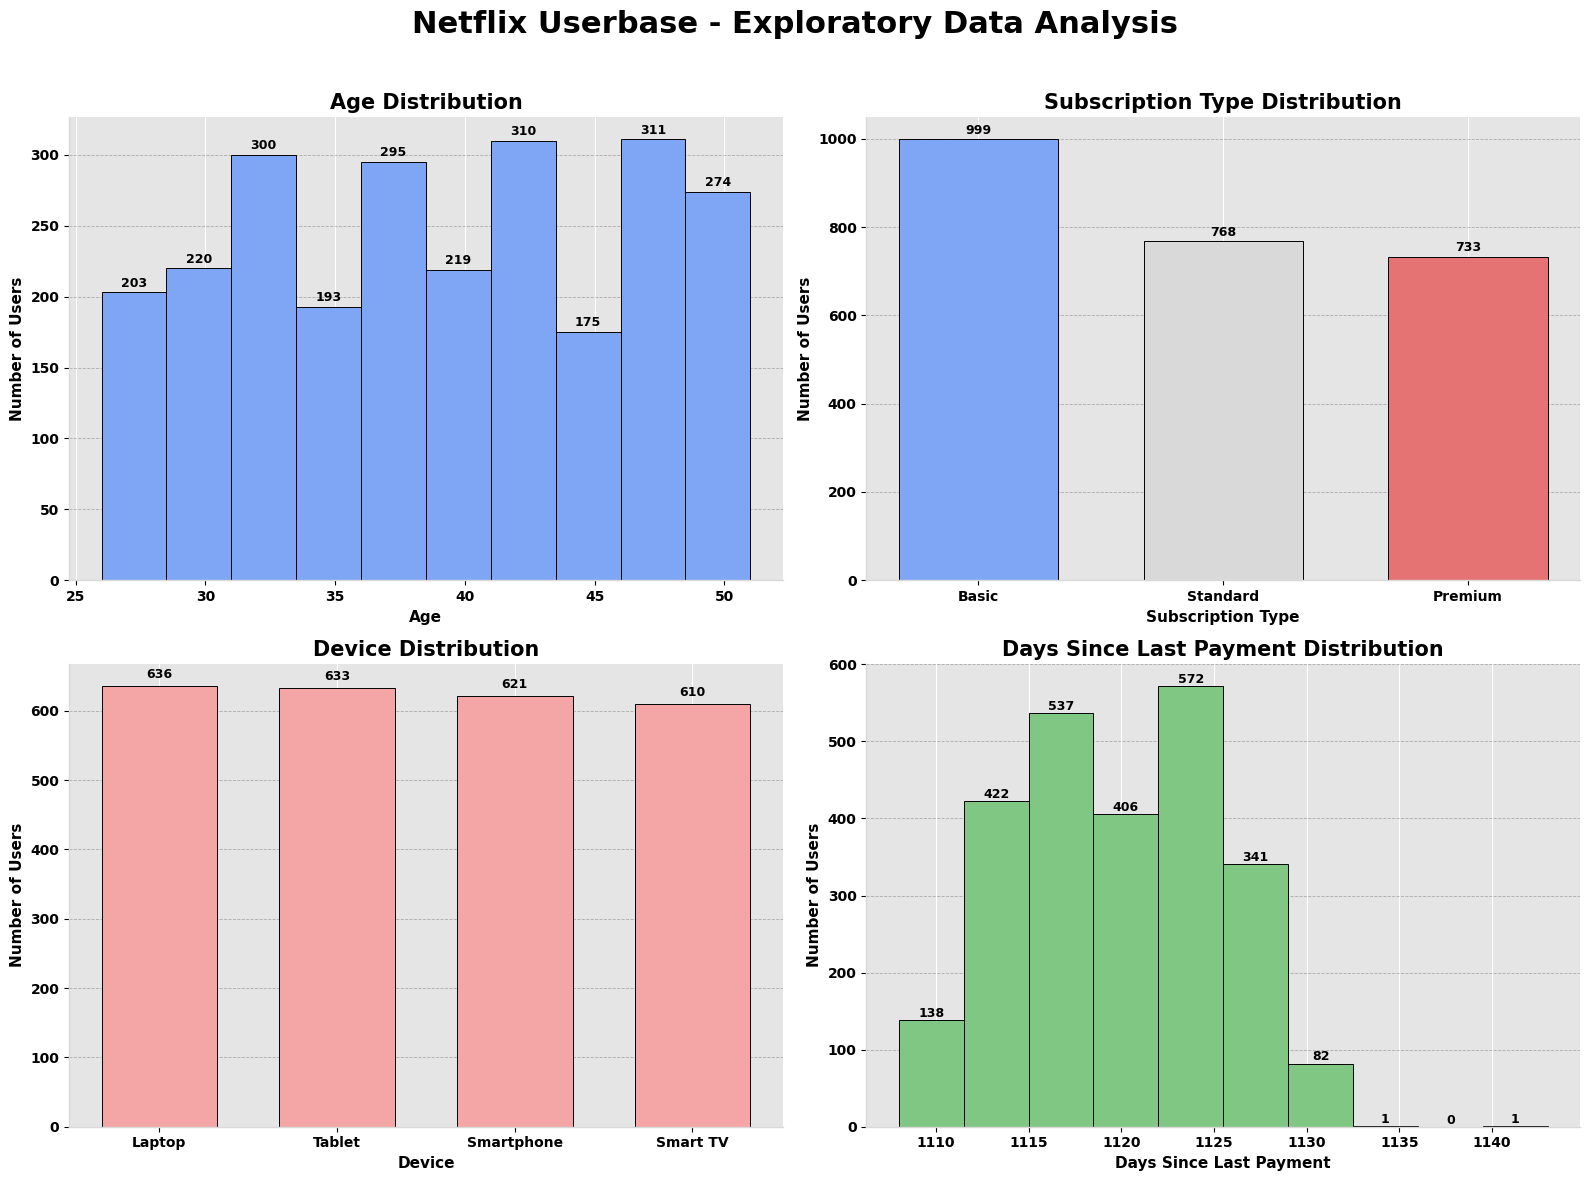

In [227]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    'Netflix Userbase - Exploratory Data Analysis',
    fontsize=22,
    fontweight='bold',
    color='black',
    y=0.98
)

counts, bins, patches = axes[0,0].hist(
    netflix_data['Age'],
    bins=10,
    color='#7FA6F5',
    edgecolor='black',
    linewidth=0.7
)

axes[0,0].set_title(
    'Age Distribution',
    fontsize=15,
    fontweight='bold',
    color='black'
)

axes[0,0].set_xlabel(
    'Age',
    fontsize=11,
    fontweight='bold',
    color='black'
)

axes[0,0].set_ylabel(
    'Number of Users',
    fontsize=11,
    fontweight='bold',
    color='black'
)

for count, patch in zip(counts, patches):

    axes[0,0].text(
        patch.get_x() + patch.get_width()/2,
        count + 4,
        f'{int(count)}',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

subscription_counts = netflix_data['Subscription Type'].value_counts()

bars = axes[0,1].bar(
    subscription_counts.index,
    subscription_counts.values,
    color=['#7FA6F5','#D9D9D9','#E57373'],
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)

axes[0,1].set_title(
    'Subscription Type Distribution',
    fontsize=15,
    fontweight='bold',
    color='black'
)

axes[0,1].set_xlabel(
    'Subscription Type',
    fontsize=11,
    fontweight='bold',
    color='black'
)

axes[0,1].set_ylabel(
    'Number of Users',
    fontsize=11,
    fontweight='bold',
    color='black'
)

for bar in bars:

    height = bar.get_height()

    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        height + 12,
        f'{int(height)}',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

device_counts = netflix_data['Device'].value_counts()

bars = axes[1,0].bar(
    device_counts.index,
    device_counts.values,
    color='#F4A6A6',
    edgecolor='black',
    linewidth=0.7,
    width=0.65
)

axes[1,0].set_title(
    'Device Distribution',
    fontsize=15,
    fontweight='bold',
    color='black'
)

axes[1,0].set_xlabel(
    'Device',
    fontsize=11,
    fontweight='bold',
    color='black'
)

axes[1,0].set_ylabel(
    'Number of Users',
    fontsize=11,
    fontweight='bold',
    color='black'
)

for bar in bars:

    height = bar.get_height()

    axes[1,0].text(
        bar.get_x() + bar.get_width()/2,
        height + 12,
        f'{int(height)}',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

counts, bins, patches = axes[1,1].hist(
    netflix_data['Days Since Last Payment'],
    bins=10,
    color='#81C784',
    edgecolor='black',
    linewidth=0.7
)

axes[1,1].set_title(
    'Days Since Last Payment Distribution',
    fontsize=15,
    fontweight='bold',
    color='black'
)

axes[1,1].set_xlabel(
    'Days Since Last Payment',
    fontsize=11,
    fontweight='bold',
    color='black'
)

axes[1,1].set_ylabel(
    'Number of Users',
    fontsize=11,
    fontweight='bold',
    color='black'
)

for count, patch in zip(counts, patches):

    axes[1,1].text(
        patch.get_x() + patch.get_width()/2,
        count + 4,
        f'{int(count)}',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

for ax in axes.flat:

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.6,
        color='black',
        alpha=0.25
    )

    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_color('#D9D9D9')
    ax.spines['bottom'].set_color('#D9D9D9')

    ax.tick_params(
        axis='x',
        colors='black',
        labelsize=10
    )

    ax.tick_params(
        axis='y',
        colors='black',
        labelsize=10
    )

    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_color('black')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_color('black')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Findings from Feature Distribution Analysis:
 - 1. Age Distribution:
The majority of users fall within the mid-age groups, indicating that Netflix attracts users from a relatively mature demographic.
 - 2. Subscription Type Distribution:
The Basic plan is the most popular subscription tier, followed by Standard and Premium plans.
 - 3. Device Usage Distribution:
Smartphones and Tablets are the most commonly used devices for accessing Netflix, with Smart TVs and Laptops also popular among users.
 - 4. Country Distribution:
The user base is concentrated in countries like the United States, Canada, and the United Kingdom, with other countries having smaller user groups.

#### Correlation Analysis

 - Correlation analysis helps identify the relationships between different numerical features in the dataset.

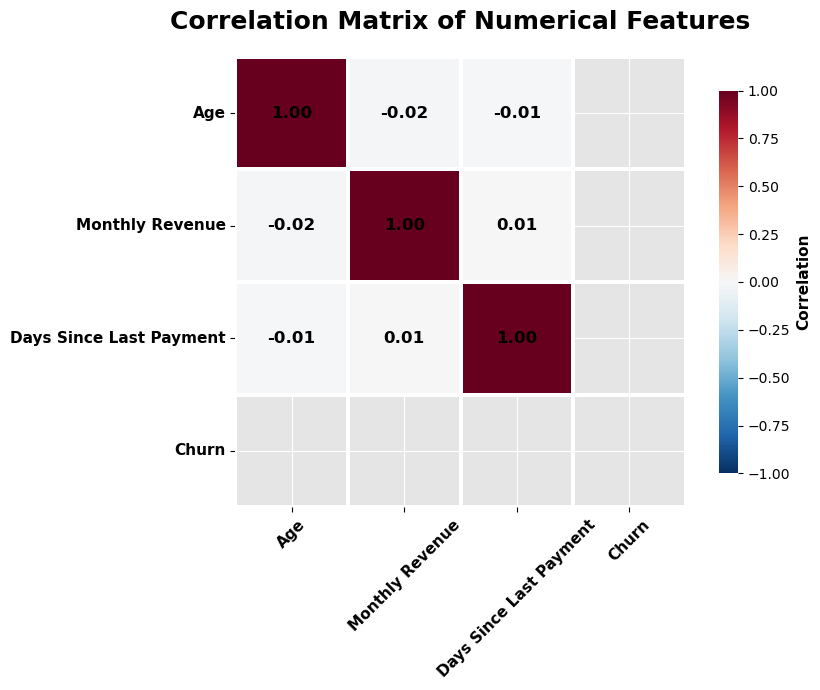

In [231]:
correlation_matrix = netflix_data[
    ['Age', 'Monthly Revenue', 'Days Since Last Payment', 'Churn']
].corr()

plt.figure(figsize=(9,7))

ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={
        'shrink':0.85,
        'label':'Correlation'
    },
    annot_kws={
        'fontsize':12,
        'fontweight':'bold',
        'color':'black'
    }
)

ax.set_title(
    'Correlation Matrix of Numerical Features',
    fontsize=18,
    fontweight='bold',
    color='black',
    pad=20
)

ax.tick_params(
    axis='x',
    labelsize=11,
    colors='black',
    rotation=45
)

ax.tick_params(
    axis='y',
    labelsize=11,
    colors='black',
    rotation=0
)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(
    labelsize=10,
    colors='black'
)
cbar.set_label(
    'Correlation',
    fontsize=11,
    fontweight='bold',
    color='black'
)

plt.tight_layout()
plt.show()

#### Findings from Correlation Analysis:
 - • Age and Monthly Revenue: There is no strong correlation between a user’s age and the revenue they generate, as indicated by the low correlation value.
 - • Days Since Last Payment and Churn: There is a strong positive correlation between Days Since Last Payment and Churn. This is expected because users who have not made a payment recently are more likely to churn.
 - • Monthly Revenue and Churn: There is a slight negative correlation between Monthly Revenue and Churn, indicating that users who generate higher revenue are less likely to churn, but the relationship is weak.

#### CONCLUSION
 - 1. Churn is a Major Issue:
• Across all subscription types, countries, and devices, the churn rate is 100%. This indicates a significant retention issue, with no users having made payments recently. Addressing this churn is crucial for improving retention and revenue generation.
 - 2. Premium Subscribers Contribute the Most to Churn and Revenue Loss:
• Premium users contribute the most to both churn and revenue loss. Targeted retention strategies, such as offering premium content or loyalty rewards, could help reduce churn among this valuable segment.
 - 3. Smartphones and Tablets are Popular but Have High Churn:
• Smartphones and Tablets are popular devices for accessing Netflix, but they also show higher churn rates. Focusing on enhancing the mobile experience or providing mobile-specific offers could reduce churn among mobile users.
 - 4. Revenue Loss Due to Churn is Substantial:
• The total revenue loss due to churn is $31,271. Implementing targeted retention strategies for at-risk users, particularly in regions with high churn (e.g., the U.S., Canada, and the U.K.), could help recover lost revenue.
 - 5. Weak Correlations Suggest No Strong Influencers Beyond Payment Behavior:
• The correlation analysis shows that Days Since Last Payment is the strongest predictor of churn, while other factors like Age and Monthly Revenue have weak correlations with churn. This highlights the importance of payment recency as a key retention metric.